# Analiza hantavirusa primenom metoda istraživanja podataka
## Tema 1, Zadatak 1.2 — Klasterovanje nad karakteristikama ponavljajućih sekvenci

Za četiri vrste hantavirusa (Hantaan, Dobrava-Belgrade, Puumala, Sin Nombre) analiziraju se
ponavljajuće sekvence (repeats) u aminokiselinskim sekvencama GPC (glycoprotein precursor) i N
(nucleocapsid protein), sa ciljem primene klasterovanja nad izvedenim karakteristikama i
poređenja dobijenih klastera sa stvarnom taksonomskom pripadnošću vrsti.

# 1. Uvod i konfiguracija

Učitavanje biblioteka, definisanje putanja i mapiranje preuzetih FASTA fajlova
(NCBI Virus baza) na (vrsta, kompletnost).

In [1]:
import re
import os
import subprocess
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import SeqIO

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

DATA_RAW = Path("data/raw")
DATA_FILTERED = Path("data/filtered")
REPEAT_OUTPUT_DIR = Path("repeat_output")
FIGURES_DIR = Path("figures")

DATA_FILTERED.mkdir(parents=True, exist_ok=True)
REPEAT_OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)


# 1. Uvod i konfiguracija (nastavak)

Mapiranje preuzetih FASTA fajlova (NCBI Virus baza) na (vrsta, kompletnost), na osnovu
broja sekvenci po fajlu i sadržaja headera (potvrđeno ranijom inspekcijom).

In [2]:
FILE_SPECIES_MAP = {
    "hantaan_all.fasta": ("hantanense", "all"),
    "hantaan_complete.fasta": ("hantanense", "complete"),
    "dobrava_all.fasta": ("dobravaense", "all"),
    "dobrava_complete.fasta": ("dobravaense", "complete"),
    "puumala_all.fasta": ("puumalaense", "all"),
    "puumala_complete.fasta": ("puumalaense", "complete"),
    "sinnombre_all.fasta": ("sinnombreense", "all"),
    "sinnombre_complete.fasta": ("sinnombreense", "complete"),
}

for fname in FILE_SPECIES_MAP:
    path = DATA_RAW / fname
    assert path.exists(), f"Fajl ne postoji: {path}"
print("Svi fajlovi pronađeni.")


Svi fajlovi pronađeni.


# 2. Klasifikacija proteina (GPC / N)

Opisi proteina u NCBI Virus bazi nisu uniformni (tipfeleri, sinonimi, različiti stilovi
anotacije). Prvo se definiše osnovna, konzervativna klasifikacija — sekvenca se
klasifikuje kao:

- **N (nucleocapsid protein)** — opis sadrži "nucleocapsid", "nucleoprotein" ili njihove
  uobičajene tipfelere.
- **GPC (glycoprotein precursor)** — opis eksplicitno pominje ceo prekursor
  ("glycoprotein precursor", "M polyprotein", "GPC"...). Pojedinačne podjedinice
  (G1, G2, Gn, Gc) su svesno isključene jer predstavljaju kraće proteinske proizvode,
  ne ceo prekursor.

In [3]:
def classify_protein(description: str) -> str | None:
    d = description.lower().strip()

    n_keywords = ["nucleocapsid", "nucleoprotein", "nucleocapsin", "nucleocapside"]
    if any(k in d for k in n_keywords):
        return "N"

    gpc_keywords = [
        "glycoprotein precursor", "glycoprotein precusor", "glicoprotein precursor",
        "m polyprotein", "gpc", "g1/g2 glycoprotein precursor",
        "g1g2 glycoprotein precursor", "envelope polyprotein",
        "precursor structural polyprotein",
    ]
    if any(k in d for k in gpc_keywords):
        return "GPC"

    return None


DESC_RE = re.compile(r"\|(.*?)\s*\[")

def extract_description(fasta_header: str) -> str:
    """fasta_header je rec.description iz Bio.SeqIO (bez '>')."""
    m = DESC_RE.search(fasta_header)
    return m.group(1).strip() if m else ""


In [4]:
test_cases = [
    "nucleocapsid protein",
    "glycoprotein precursor",
    "envelope glycoprotein",
    "G1 glycoprotein, partial",
    "RNA-dependent RNA polymerase",
    "M polyprotein",
    "GPC",
]
for t in test_cases:
    print(t, "->", classify_protein(t))


nucleocapsid protein -> N
glycoprotein precursor -> GPC
envelope glycoprotein -> None
G1 glycoprotein, partial -> None
RNA-dependent RNA polymerase -> None
M polyprotein -> GPC
GPC -> GPC


In [5]:
from collections import Counter

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    counter = Counter()
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        counter[label] += 1
    print(f"{fname:25s} {species:15s} {completeness:9s} -> {dict(counter)}")


hantaan_all.fasta         hantanense      all       -> {'N': 695, None: 1356, 'GPC': 146}
hantaan_complete.fasta    hantanense      complete  -> {'N': 90, None: 156, 'GPC': 2}
dobrava_all.fasta         dobravaense     all       -> {None: 319, 'GPC': 145, 'N': 311}
dobrava_complete.fasta    dobravaense     complete  -> {None: 8, 'GPC': 13, 'N': 18}
puumala_all.fasta         puumalaense     all       -> {'N': 1787, None: 1549, 'GPC': 512}
puumala_complete.fasta    puumalaense     complete  -> {'N': 56, None: 64, 'GPC': 22}
sinnombre_all.fasta       sinnombreense   all       -> {None: 197, 'GPC': 125, 'N': 130}
sinnombre_complete.fasta  sinnombreense   complete  -> {None: 10, 'GPC': 3, 'N': 6}


Primetan je problem kod `hantaan_complete` — samo 2 sekvence klasifikovane kao GPC.
Sledeći korak je da se istraži šta se krije u kategoriji `None` za sve "complete" fajlove,
da se proveri da li se tu gubi nešto relevantno.

In [6]:
none_descriptions = Counter()

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    if completeness != "complete":
        continue
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        if classify_protein(desc) is None:
            none_descriptions[desc] += 1

for desc, count in none_descriptions.most_common():
    print(f"{count:4d}  {desc}")


  99  RNA-dependent RNA polymerase
  75  glycoprotein
   6  RNA polymerase
   6  glycoproteins precursor
   6  NSs
   6  RNA-dependet RNA polymerase
   5  nonstructural protein
   5  small non-structural protein
   4  RNA-directed RNA polymerase L
   3  putative RNA-dependent RNA polymerase
   3  glycoprotein polyprotein precursor
   2  G1 and G2 glycoprotein
   2  polymerase
   2  RNA-dependent RNA polymerase protein
   2  viral RNA polymerase (L protein)
   1  envelope glycoprotein G2 (see comment), partial
   1  envelope glycoprotein G1 (see comment), partial
   1  putative polymerase
   1  hypothetical protein HTNVsMgp1
   1  hypothetical protein HTNVsSgp1
   1  GP
   1  envelope glycoprotein
   1  polymerase protein
   1  RdRp
   1  L protein
   1  polyprotein
   1  putative nonstructural protein


Uočena su dva odvojena nalaza:
1. Dva keyword bag-a u trenutnoj klasifikaciji — "glycoproteins precursor" (množina) i
   "glycoprotein polyprotein precursor" (drugačiji redosled reči) nisu uhvaćeni, iako
   su nedvosmisleno GPC.
2. Najveći gubitak je opis "glycoprotein" bez ikakvog dodatka (75 sekvenci) — potrebno je
   proveriti da li se ove sekvence koncentrišu baš kod hantaan_complete (gde nedostaje GPC),
   i da li predstavljaju punu dužinu proteina ili fragmente.

In [7]:
glycoprotein_only_by_species = Counter()

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    if completeness != "complete":
        continue
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        if desc.strip().lower() == "glycoprotein":
            glycoprotein_only_by_species[species] += 1

print(glycoprotein_only_by_species)


Counter({'hantanense': 66, 'puumalaense': 6, 'sinnombreense': 3})


In [8]:
import statistics

lengths_precursor = []
lengths_bare = []

for rec in SeqIO.parse(DATA_RAW / "hantaan_complete.fasta", "fasta"):
    desc = extract_description(rec.description).strip().lower()
    if "precursor" in desc and "glycoprotein" in desc:
        lengths_precursor.append(len(rec.seq))
    elif desc == "glycoprotein":
        lengths_bare.append(len(rec.seq))

print("precursor:", lengths_precursor)
print("bare glycoprotein - broj:", len(lengths_bare))
print("bare glycoprotein - min/max/mean:", min(lengths_bare), max(lengths_bare), statistics.mean(lengths_bare))


precursor: []
bare glycoprotein - broj: 66
bare glycoprotein - min/max/mean: 1135 1135 1135


In [9]:
lengths_confirmed_gpc = []

for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description).strip().lower()
        if "precursor" in desc and "glycoprotein" in desc:
            lengths_confirmed_gpc.append((species, len(rec.seq)))

from collections import defaultdict
by_species = defaultdict(list)
for sp, l in lengths_confirmed_gpc:
    by_species[sp].append(l)

for sp, ls in by_species.items():
    print(sp, "n=", len(ls), "min/max:", min(ls), max(ls))


hantanense n= 127 min/max: 89 1135
dobravaense n= 150 min/max: 61 1135
puumalaense n= 506 min/max: 69 1148
sinnombreense n= 114 min/max: 67 1140


**Zaključak:** maksimalne dužine potvrđenih GPC precursor sekvenci (1135–1148 AK, u
zavisnosti od vrste) poklapaju se sa dužinom "golih" `glycoprotein` opisa (1135 AK kod
hantanense). Ovo potvrđuje da je "goli" opis zapravo pun GPC precursor, samo generičnije
anotiran — treba ga uključiti u GPC klasu, ali uz proveru dužine (jer minimalne vrednosti
kod "precursor" opisa, 61–89 AK, pokazuju da i eksplicitno označeni "precursor" zapisi mogu
biti parcijalni fragmenti). Provera dužine se uvodi u sledećoj sekciji.

Pre toga, treba proveriti da li se ovaj obrazac (goli opis = puna dužina) drži i kod ostalih
vrsta gde se "goli" `glycoprotein` opis javlja (puumalaense, sinnombreense).

In [10]:
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description).strip().lower()
        if desc == "glycoprotein":
            print(species, completeness, rec.id, len(rec.seq))


hantanense all YCK98854.1 1135
hantanense all XXH92413.1 1135
hantanense all XXH92412.1 1135
hantanense all XXH92411.1 1135
hantanense all XXH92410.1 1135
hantanense all XXH92409.1 1135
hantanense all XXH92408.1 1135
hantanense all XXH92407.1 1135
hantanense all XXH92406.1 1135
hantanense all XXH92404.1 1135
hantanense all XXH92403.1 1135
hantanense all XHY08806.1 1135
hantanense all XHY08805.1 1135
hantanense all XHY08804.1 1135
hantanense all XHY08803.1 1135
hantanense all XHY08802.1 1135
hantanense all XHY08801.1 1135
hantanense all XHY08800.1 1135
hantanense all XHY08799.1 1135
hantanense all XHY08798.1 1135
hantanense all XHV16825.1 1135
hantanense all XHV16824.1 1135
hantanense all XHV16823.1 1135
hantanense all XHV16822.1 1135
hantanense all XHV16821.1 1135
hantanense all XHP16135.1 1135
hantanense all XHP16134.1 1135
hantanense all XHP16133.1 1135
hantanense all XHP16132.1 1135
hantanense all XHP16131.1 1135
hantanense all XHP16130.1 1135
hantanense all XHP16129.1 1135
hantanen

**Zaključak istraživanja:**
1. Dva keyword baga treba popraviti: "glycoproteins precursor" i "glycoprotein polyprotein precursor".
2. "Goli" opis `glycoprotein` treba uključiti u GPC klasu.
3. Ni tekst opisa ("precursor", "partial") ni sam po sebi nisu pouzdan pokazatelj pune
   dužine sekvence (postoje kratki fragmenti bez reči "partial" u opisu, npr. sinnombreense
   990/985/550 AK). Zato je neophodan nezavisan filter na osnovu stvarne dužine sekvence,
   koji se uvodi u Sekciji 3.

Na osnovu ovoga, finalizuje se `classify_protein()` funkcija.

In [11]:
def classify_protein(description: str) -> str | None:
    d = description.lower().strip()

    n_keywords = ["nucleocapsid", "nucleoprotein", "nucleocapsin", "nucleocapside"]
    if any(k in d for k in n_keywords):
        return "N"

    gpc_keywords = [
        "glycoprotein precursor", "glycoprotein precusor", "glicoprotein precursor",
        "glycoproteins precursor", "glycoprotein polyprotein precursor",
        "m polyprotein", "gpc", "g1/g2 glycoprotein precursor",
        "g1g2 glycoprotein precursor", "envelope polyprotein",
        "precursor structural polyprotein",
    ]
    if any(k in d for k in gpc_keywords):
        return "GPC"

    # "goli" opis "glycoprotein" - dokazano da odgovara punoj duzini GPC-a
    # (vidi istrazivanje iznad); puna duzina se dodatno proverava u Sekciji 3
    if d == "glycoprotein":
        return "GPC"

    return None


# 3. Filter dužine sekvence

Klasifikacija po opisu nije dovoljna sama po sebi — pokazano je da opis ne pominje uvek
pouzdano da li je sekvenca puna ili parcijalna. Sledeći korak je provera distribucije
dužina po tipu proteina, da se utvrde razumni pragovi za filtriranje fragmenata.

In [12]:
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    counter = Counter()
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        counter[label] += 1
    print(f"{fname:25s} {species:15s} {completeness:9s} -> {dict(counter)}")


hantaan_all.fasta         hantanense      all       -> {'N': 695, None: 1081, 'GPC': 421}
hantaan_complete.fasta    hantanense      complete  -> {'N': 90, 'GPC': 68, None: 90}
dobrava_all.fasta         dobravaense     all       -> {None: 318, 'GPC': 146, 'N': 311}
dobrava_complete.fasta    dobravaense     complete  -> {None: 8, 'GPC': 13, 'N': 18}
puumala_all.fasta         puumalaense     all       -> {'N': 1787, None: 1520, 'GPC': 541}
puumala_complete.fasta    puumalaense     complete  -> {'N': 56, None: 49, 'GPC': 37}
sinnombre_all.fasta       sinnombreense   all       -> {None: 173, 'GPC': 149, 'N': 130}
sinnombre_complete.fasta  sinnombreense   complete  -> {None: 7, 'GPC': 6, 'N': 6}


Sada se proverava distribucija dužina sekvenci po tipu proteina, na osnovu ove
(proširene) klasifikacije, da bi se utvrdili razumni pragovi za filtriranje fragmenata.

          count        mean         std   min     5%    25%    50%     75%  \
protein                                                                      
GPC      1381.0  657.797248  469.636675  53.0   91.0  190.0  484.0  1135.0   
N        3093.0  307.078565  132.759268  34.0  100.0  177.0  336.0   429.0   

            95%     max  
protein                  
GPC      1148.0  1149.0  
N         433.0  1140.0  


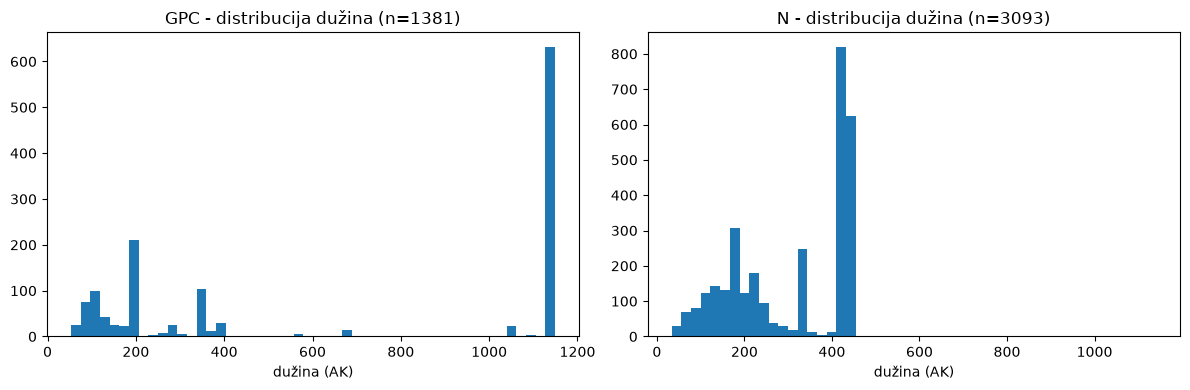

In [13]:
rows = []
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        if label is not None:
            rows.append({"species": species, "completeness": completeness,
                         "protein": label, "length": len(rec.seq)})

length_check_df = pd.DataFrame(rows)
print(length_check_df.groupby("protein")["length"].describe(percentiles=[.05, .25, .5, .75, .95]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, protein in zip(axes, ["GPC", "N"]):
    subset = length_check_df[length_check_df.protein == protein]["length"]
    ax.hist(subset, bins=50)
    ax.set_title(f"{protein} - distribucija dužina (n={len(subset)})")
    ax.set_xlabel("dužina (AK)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "duzina_distribucija.png", dpi=150, bbox_inches="tight")
plt.show()


Na osnovu grafika, pragovi su izabrani na sledeći način:

- **GPC**: donja granica 1000 AK (glavni pik je na ~1130–1150, prazan prostor je između
  ~400 i ~1000, pa svaka vrednost u tom rasponu daje isti rezultat).
- **N**: donji prag 400 AK (glavni pik na ~420–440).

In [14]:
LENGTH_THRESHOLDS = {"GPC": 1000, "N": 400}

def is_full_length(protein_label: str, seq_length: int) -> bool:
    return seq_length >= LENGTH_THRESHOLDS[protein_label]


In [15]:
for fname, (species, completeness) in FILE_SPECIES_MAP.items():
    counter = Counter()
    for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
        desc = extract_description(rec.description)
        label = classify_protein(desc)
        if label is not None and not is_full_length(label, len(rec.seq)):
            label = None
        counter[label] += 1
    print(f"{fname:25s} {species:15s} {completeness:9s} -> {dict(counter)}")


hantaan_all.fasta         hantanense      all       -> {'N': 524, None: 1380, 'GPC': 293}
hantaan_complete.fasta    hantanense      complete  -> {'N': 90, 'GPC': 68, None: 90}
dobrava_all.fasta         dobravaense     all       -> {None: 650, 'GPC': 35, 'N': 90}
dobrava_complete.fasta    dobravaense     complete  -> {None: 9, 'GPC': 12, 'N': 18}
puumala_all.fasta         puumalaense     all       -> {'N': 600, None: 3098, 'GPC': 150}
puumala_complete.fasta    puumalaense     complete  -> {'N': 56, None: 49, 'GPC': 37}
sinnombre_all.fasta       sinnombreense   all       -> {None: 323, 'GPC': 62, 'N': 67}
sinnombre_complete.fasta  sinnombreense   complete  -> {None: 7, 'GPC': 6, 'N': 6}


# 4. Filtriranje i čuvanje FASTA fajlova

Kombinuju se sva tri filtera: klasifikacija proteina, provera pune dužine, i uklanjanje
sekvenci sa dvosmislenim karakterima (ambiguous characters = 0, kako zahteva uputstvo
zadatka). Za svaku kombinaciju (vrsta, kompletnost, protein) čuva se poseban FASTA fajl.

In [16]:
def filter_and_save():
    summary = []

    for fname, (species, completeness) in FILE_SPECIES_MAP.items():
        buckets = {"N": [], "GPC": []}

        for rec in SeqIO.parse(DATA_RAW / fname, "fasta"):
            desc = extract_description(rec.description)
            label = classify_protein(desc)

            if label is None:
                continue
            if not is_full_length(label, len(rec.seq)):
                continue

            seq_str = str(rec.seq).replace("*", "")
            standard_aa = set("ACDEFGHIKLMNPQRSTVWY")
            if any(ch.upper() not in standard_aa for ch in seq_str):
                continue  # ambiguous characters - iskljucujemo (uputstvo zadatka)

            buckets[label].append(rec)

        for protein, records in buckets.items():
            out_path = DATA_FILTERED / f"{species}_{completeness}_{protein}.fasta"
            SeqIO.write(records, out_path, "fasta")
            summary.append({
                "species": species, "completeness": completeness,
                "protein": protein, "n_sequences": len(records),
            })

    return pd.DataFrame(summary)


summary_df = filter_and_save()
summary_df


,species,completeness,protein,n_sequences
0,hantanense,all,N,522
1,hantanense,all,GPC,292
2,hantanense,complete,N,90
3,hantanense,complete,GPC,67
4,dobravaense,all,N,90
5,dobravaense,all,GPC,31
6,dobravaense,complete,N,18
7,dobravaense,complete,GPC,11
8,puumalaense,all,N,577
9,puumalaense,all,GPC,135


# 5. Pokretanje RepeatsPlus/StatRepeats alata

Alat `StatRepeatsNoDB` (RepeatsPlus paket, Bioinformatics Research Group, Matematički
fakultet Beograd) pokreće se nad svakim od 16 filtriranih FASTA fajlova, tražeći tačna
(exact) ponavljanja motiva minimalne dužine 3 aminokiseline (parametar izabran na osnovu
preporuke samog alata — za alfabet od 20 aminokiselina, dužina motiva 2 je statistički
premala da bi rezultati bili pouzdani).

In [17]:
REPEATS_TOOL = Path("repeats_tool/Programs/StatRepeats/Linux/StatRepeatsNoDB").resolve()
TOOL_DIR = REPEATS_TOOL.parent
FRAGMENT_LENGTH = 3


def run_statrepeats(fasta_path: Path, output_path: Path):
    # putanje se prosledjuju kao relativne (u odnosu na cwd=TOOL_DIR) jer alat
    # pogresno tumaci apsolutne putanje koje pocinju "/" kao opcije komandne linije
    fasta_rel = os.path.relpath(fasta_path.resolve(), start=TOOL_DIR)
    output_rel = os.path.relpath(output_path.resolve(), start=TOOL_DIR)

    result = subprocess.run(
        [str(REPEATS_TOOL), fasta_rel, str(FRAGMENT_LENGTH),
         "-protein", "-output", output_rel],
        capture_output=True, text=True, cwd=TOOL_DIR,
    )
    return result


In [19]:
results_log = []

for fasta_path in sorted(DATA_FILTERED.glob("*.fasta")):
    output_path = REPEAT_OUTPUT_DIR / f"{fasta_path.stem}.txt"
    result = run_statrepeats(fasta_path, output_path)
    results_log.append({
        "file": fasta_path.name,
        "returncode": result.returncode,
        "output_exists": output_path.exists(),
        "output_size": output_path.stat().st_size if output_path.exists() else 0,
    })
    print(f"{fasta_path.name:40s} rc={result.returncode}  "
          f"out_size={results_log[-1]['output_size']}")

log_df = pd.DataFrame(results_log)
log_df


dobravaense_all_GPC.fasta                rc=0  out_size=119570
dobravaense_all_N.fasta                  rc=0  out_size=16957
dobravaense_complete_GPC.fasta           rc=0  out_size=42887
dobravaense_complete_N.fasta             rc=0  out_size=3543
hantanense_all_GPC.fasta                 rc=0  out_size=550973
hantanense_all_N.fasta                   rc=0  out_size=52299
hantanense_complete_GPC.fasta            rc=0  out_size=117617
hantanense_complete_N.fasta              rc=0  out_size=9080
puumalaense_all_GPC.fasta                rc=0  out_size=712778
puumalaense_all_N.fasta                  rc=0  out_size=365277
puumalaense_complete_GPC.fasta           rc=0  out_size=201106
puumalaense_complete_N.fasta             rc=0  out_size=28889
sinnombreense_all_GPC.fasta              rc=0  out_size=108043
sinnombreense_all_N.fasta                rc=0  out_size=20791
sinnombreense_complete_GPC.fasta         rc=0  out_size=15863
sinnombreense_complete_N.fasta           rc=0  out_size=2615


,file,returncode,output_exists,output_size
0,dobravaense_all_GPC.fasta,0,True,119570
1,dobravaense_all_N.fasta,0,True,16957
2,dobravaense_complete_GPC.fasta,0,True,42887
3,dobravaense_complete_N.fasta,0,True,3543
4,hantanense_all_GPC.fasta,0,True,550973
5,hantanense_all_N.fasta,0,True,52299
6,hantanense_complete_GPC.fasta,0,True,117617
7,hantanense_complete_N.fasta,0,True,9080
8,puumalaense_all_GPC.fasta,0,True,712778
9,puumalaense_all_N.fasta,0,True,365277


# 6. Parsiranje izlaza i feature ekstrakcija

Izlaz alata sadrži, za svaku sekvencu, agregatnu statistiku broja pronađenih ponavljanja
po dužini motiva (linije oblika `Total for length X is Y.`). Ove vrednosti se parsiraju
u feature tabelu — jedan red po sekvenci. Dodatno se uključuje i dužina sekvence, kao i
normalizovane verzije karakteristika (broj ponavljanja / dužina sekvence), kako bi se
razdvojio efekat same dužine sekvence od "gustine" ponavljanja.

In [20]:
BLOCK_START_RE = re.compile(r"^(\S+) Alphabet size is (\d+)\.")
TOTAL_RE = re.compile(r"^Total for length (\d+) is (\d+)\.")


def parse_statrepeats_output(filepath: Path) -> dict[str, dict[int, int]]:
    """Vraca {seq_id: {duzina_motiva: broj_ponavljanja}}"""
    results = {}
    current_id = None

    with open(filepath) as f:
        for line in f:
            m_start = BLOCK_START_RE.match(line)
            if m_start:
                current_id = m_start.group(1)
                results[current_id] = {}
                continue

            m_total = TOTAL_RE.match(line)
            if m_total and current_id is not None:
                length = int(m_total.group(1))
                count = int(m_total.group(2))
                results[current_id][length] = count

    return results


test_result = parse_statrepeats_output(REPEAT_OUTPUT_DIR / "hantanense_complete_GPC.txt")
print("broj sekvenci:", len(test_result))
print(list(test_result.items())[:5])


broj sekvenci: 67
[('XHP16135.1', {3: 14, 4: 7}), ('XHP16134.1', {3: 14, 4: 7}), ('XHP16133.1', {3: 14, 4: 7}), ('XHP16132.1', {3: 14, 4: 7}), ('XHP16131.1', {3: 14, 4: 7})]


In [21]:
def build_feature_table():
    rows = []
    for txt_path in sorted(REPEAT_OUTPUT_DIR.glob("*.txt")):
        species, completeness, protein = txt_path.stem.rsplit("_", 2)
        parsed = parse_statrepeats_output(txt_path)

        for seq_id, length_counts in parsed.items():
            row = {"accession": seq_id, "species": species,
                   "completeness": completeness, "protein": protein}
            for length, count in length_counts.items():
                row[f"repeats_len_{length}"] = count
            rows.append(row)

    df = pd.DataFrame(rows)
    repeat_cols = [c for c in df.columns if c.startswith("repeats_len_")]
    df[repeat_cols] = df[repeat_cols].fillna(0).astype(int)
    return df


def add_sequence_length(df):
    lengths = {}
    for fasta_path in DATA_FILTERED.glob("*.fasta"):
        for rec in SeqIO.parse(fasta_path, "fasta"):
            lengths[rec.id] = len(rec.seq)
    df = df.copy()
    df["seq_length"] = df["accession"].map(lengths)
    return df


def add_normalized_features(df):
    df = df.copy()
    repeat_cols = [c for c in df.columns if c.startswith("repeats_len_")]
    for col in repeat_cols:
        df[f"{col}_norm"] = df[col] / df["seq_length"]
    return df


feature_df = build_feature_table()
feature_df = add_sequence_length(feature_df)
feature_df = add_normalized_features(feature_df)

print(feature_df.shape)
feature_df.head()


(2034, 15)


,accession,species,completeness,protein,repeats_len_3,repeats_len_4,repeats_len_6,repeats_len_5,repeats_len_8,seq_length,repeats_len_3_norm,repeats_len_4_norm,repeats_len_6_norm,repeats_len_5_norm,repeats_len_8_norm
0,YFI28168.1,dobravaense,all,GPC,96,10,0,0,0,1135,0.084581,0.008811,0.0,0.0,0.0
1,YFI28166.1,dobravaense,all,GPC,95,10,0,0,0,1135,0.083700,0.008811,0.0,0.0,0.0
2,UVB78522.1,dobravaense,all,GPC,99,0,0,0,0,1135,0.087225,0.000000,0.0,0.0,0.0
3,UVB78521.1,dobravaense,all,GPC,102,0,0,0,0,1135,0.089868,0.000000,0.0,0.0,0.0
4,UTK64190.1,dobravaense,all,GPC,87,0,0,0,0,1095,0.079452,0.000000,0.0,0.0,0.0
